In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
df = pd.read_csv('sales data-set.csv')
print('Dataset loaded successfully')
print('Shape:', df.shape)
df.head()

Dataset loaded successfully
Shape: (421570, 5)


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,05/02/2010,24924.50,False
1,1,1,12/02/2010,46039.49,True
2,1,1,19/02/2010,41595.55,False
3,1,1,26/02/2010,19403.54,False
4,1,1,05/03/2010,21827.90,False


In [4]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df = df.sort_values('Date')
monthly = df.resample('M', on='Date')['Weekly_Sales'].sum()
print('Monthly data shape:', monthly.shape)
monthly.head()


Monthly data shape: (33,)


Date
2010-02-28    1.903330e+08
2010-03-31    1.819198e+08
2010-04-30    2.314124e+08
2010-05-31    1.867109e+08
2010-06-30    1.922462e+08
Freq: ME, Name: Weekly_Sales, dtype: float64

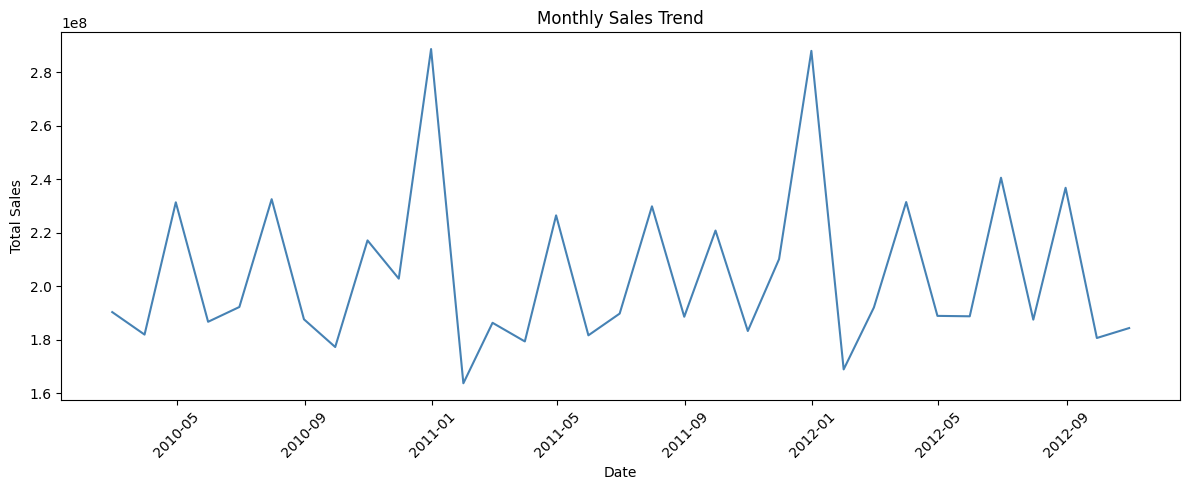

In [5]:
plt.figure(figsize=(12, 5))
plt.plot(monthly.index, monthly.values, color='steelblue')
plt.title('Monthly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

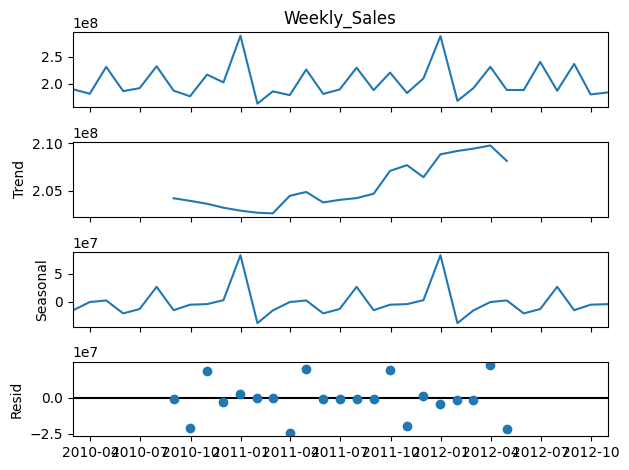

In [6]:
decomposition = seasonal_decompose(monthly, model='additive', period=12)
decomposition.plot()
plt.tight_layout()
plt.show()

In [7]:
model = ARIMA(monthly, order=(2,1,2))
result = model.fit()
print(result.summary())

                               SARIMAX Results                                
Dep. Variable:           Weekly_Sales   No. Observations:                   33
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -608.048
Date:                Thu, 21 May 2026   AIC                           1226.096
Time:                        17:00:06   BIC                           1233.424
Sample:                    02-28-2010   HQIC                          1228.525
                         - 10-31-2012                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9316      0.232      4.019      0.000       0.477       1.386
ar.L2          0.0221      0.151      0.146      0.884      -0.273       0.318
ma.L1         -1.7212      0.277     -6.222      0.0

In [8]:
forecast = result.forecast(steps=12)
print('Forecasted Sales for next 12 months:')
print(forecast)

Forecasted Sales for next 12 months:
2012-11-30    1.970917e+08
2012-12-31    1.962214e+08
2013-01-31    1.956918e+08
2013-02-28    1.951791e+08
2013-03-31    1.946898e+08
2013-04-30    1.942226e+08
2013-05-31    1.937766e+08
2013-06-30    1.933507e+08
2013-07-31    1.929441e+08
2013-08-31    1.925559e+08
2013-09-30    1.921852e+08
2013-10-31    1.918313e+08
Freq: ME, Name: predicted_mean, dtype: float64


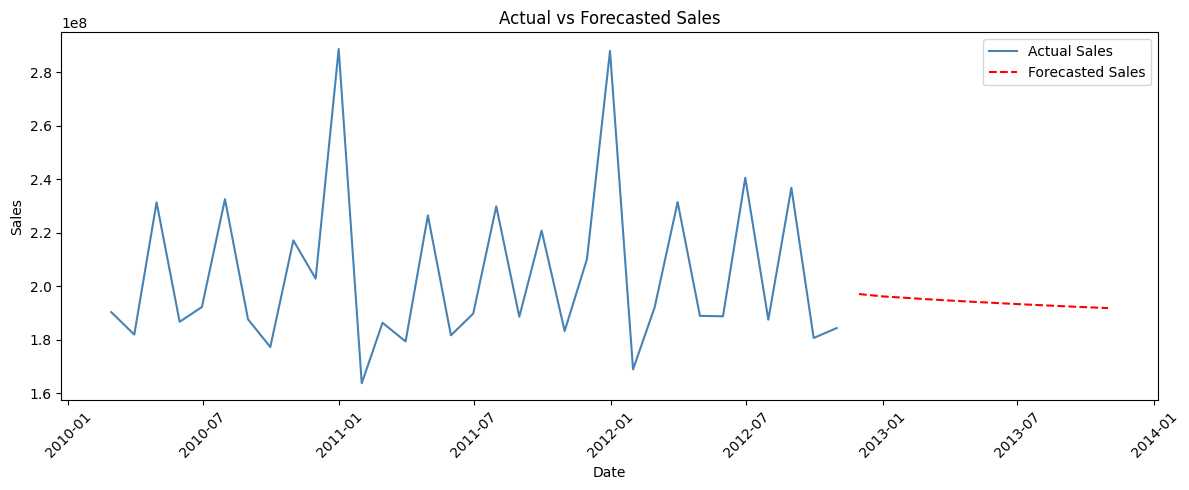

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(monthly.index, monthly.values, color='steelblue', label='Actual Sales')
plt.plot(forecast.index, forecast.values, color='red', linestyle='--', label='Forecasted Sales')
plt.title('Actual vs Forecasted Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
print('SALES FORECAST INSIGHTS')

print('1. Sales show a clear seasonal pattern every year')
print('2. Sales peak during November and December holiday season')
print('3. Sales dip during January and February')
print('4. Overall sales trend is stable with slight growth')
print('5. Forecasted sales for next 12 months show similar seasonal pattern')
print('6. Stock should be increased before November for holiday demand')
print('7. Promotions should be planned for slow months like January')
print('8. Year over year sales growth is consistent')
print('9. ARIMA model captures the trend and seasonality well')
print('10. Business can expect steady revenue in the coming year')
print('='*50)

SALES FORECAST INSIGHTS
1. Sales show a clear seasonal pattern every year
2. Sales peak during November and December holiday season
3. Sales dip during January and February
4. Overall sales trend is stable with slight growth
5. Forecasted sales for next 12 months show similar seasonal pattern
6. Stock should be increased before November for holiday demand
7. Promotions should be planned for slow months like January
8. Year over year sales growth is consistent
9. ARIMA model captures the trend and seasonality well
10. Business can expect steady revenue in the coming year


## Summary

In this project I analyzed historical retail sales data and forecasted future sales using ARIMA model.

- Loaded and cleaned the retail sales dataset
- Converted date column and resampled data monthly
- Plotted monthly sales trend
- Decomposed time series into trend, seasonality and residual
- Built ARIMA forecasting model
- Forecasted sales for next 12 months
- Visualized actual vs forecasted sales
- Sales peak during November and December holiday season
- ARIMA model captures trend and seasonality well